In [20]:
import numpy as np
import pandas as pd
import json
import random as rd
import matplotlib.pyplot as plt

In [21]:
state = None

with open("state_indices.txt", 'r') as f:
    states = json.load(f)
    f.close

state_names = list(states.keys())
print(state_names)

['alabama', 'alaska', 'arizona', 'arkansas', 'california', 'colorado', 'connecticut', 'delaware', 'florida', 'georgia', 'hawaii', 'idaho', 'illinois', 'indiana', 'iowa', 'kansas', 'kentucky', 'louisiana', 'maine', 'maryland', 'massachusetts', 'michigan', 'minnesota', 'mississippi', 'missouri', 'montana', 'nebraska', 'nevada', 'new_hampshire', 'new_jersey', 'new_mexico', 'new_york', 'north_carolina', 'north_dakota', 'ohio', 'oklahoma', 'oregon', 'pennsylvania', 'rhode_island', 'south_carolina', 'south_dakota', 'tennessee', 'texas', 'utah', 'vermont', 'virginia', 'washington', 'west_virginia', 'wisconsin', 'wyoming']


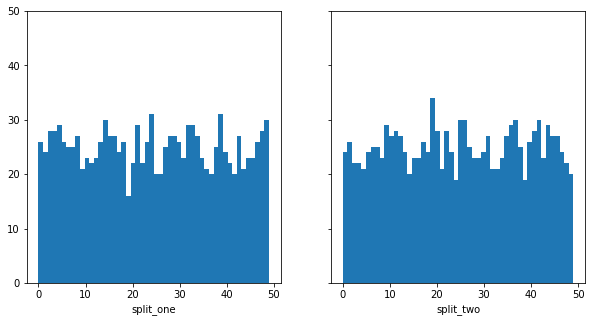

In [45]:
all_pids = [i for i in range(0, len(states))]

first_all = []
second_all = []

split_jsons = []

for i in range(50):
    first_split_indicies = rd.sample(all_pids, 25)

    first_split_set = set(first_split_indicies)

    second_split_indicies = []

    for indx in all_pids:
        if indx not in first_split_set:
            second_split_indicies.append(indx)

    first_split = {}
    second_split = {}

    for s1, s2 in zip(first_split_indicies, second_split_indicies):
        first_split[state_names[s1]] = s1
        second_split[state_names[s2]] = s2

    # print(first_split)

    first_all.extend(first_split_indicies)
    second_all.extend(second_split_indicies)

    data = {"split_one":first_split, "split_two":second_split}

    fp = open(("state_split_%d.json" % i), 'w+')

    json.dump(data, fp)
    fp.close()

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

axs[0].hist(first_all, 50)
axs[0].set_ylim(0, 50)
axs[0].set_xlabel("split_one")
axs[1].hist(second_all, 50)
axs[1].set_xlabel("split_two")

fig.savefig("state_split.png")

    


(0.0, 50.0)

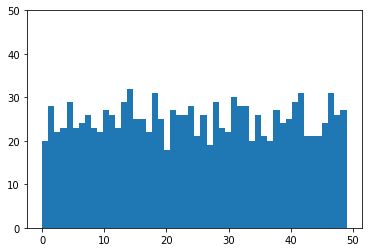

In [34]:
plt.hist(first_all, 50)
plt.ylim(0, 50)

(0.0, 50.0)

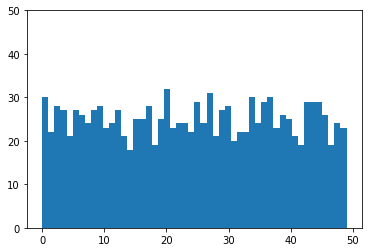

In [35]:
plt.hist(second_all, 50)
plt.ylim(0, 50)